In [ ]:
%pip install -q -r ../requirements-notebooks.txt

# 01 — Explore river data

Goal: load all CSVs, clean glitches, resample to 1-min grid, then characterize the upstream → Centro signal via cross-correlation. Output of this notebook feeds Phase 2 (SARIMAX lags).

Napo (station-02) and Balinad (station-03) are upstream of Centro (station-01). We expect their water level / flow rate to lead Centro's by some lag — that's the actual ML signal.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from statsmodels.tsa.stattools import acf, adfuller, pacf

from lib.preprocess import build_wide, cross_correlation, load_csv_dir

DATASET_DIR = Path.cwd().parent.parent / "dataset"
DATASET_DIR

WindowsPath('c:/Users/satui/OneDrive/Desktop/04 COMISSION_PROJECTS/bup-cpe-river/dataset')

In [2]:
long = load_csv_dir(DATASET_DIR)
print(long.shape, long['station_id'].value_counts().to_dict())
long.head()

(4547, 4) {'station-02': 1540, 'station-03': 1518, 'station-01': 1489}


,timestamp,station_id,water_level,flow_rate
0,2026-04-16 15:57:43,station-01,14.39413,40.0
1,2026-04-16 15:58:45,station-01,14.45415,45.0
2,2026-04-16 15:58:48,station-02,31.88998,5.0
3,2026-04-16 15:59:25,station-03,16.43211,46.0
4,2026-04-16 15:59:48,station-01,13.03070,45.0


In [3]:
wide = build_wide(long)
print(f'Wide shape: {wide.shape}')
print(f'Time range: {wide.index.min()} -> {wide.index.max()}')
wide.describe()

Wide shape: (1790, 6)
Time range: 2026-04-16 15:57:00 -> 2026-04-29 17:02:00


,station-01_water_level,station-01_flow_rate,station-02_water_level,station-02_flow_rate,station-03_water_level,station-03_flow_rate
count,1773.000000,1773.000000,1778.000000,1778.000000,1768.000000,1768.000000
mean,17.391820,42.621545,34.326175,5.721597,20.129981,35.247738
std,4.640754,6.396822,5.600351,3.653322,16.265860,9.869938
min,3.083710,0.000000,21.314150,0.000000,12.070310,0.000000
25%,16.117710,40.000000,33.822220,5.000000,16.708668,33.000000
50%,17.335360,45.000000,34.113770,5.500000,17.066670,38.000000
75%,18.089970,45.000000,34.719730,6.000000,18.118530,41.000000
max,96.139610,55.000000,115.896400,45.000000,165.168350,46.000000


## Time-series visualization (post-cleaning)

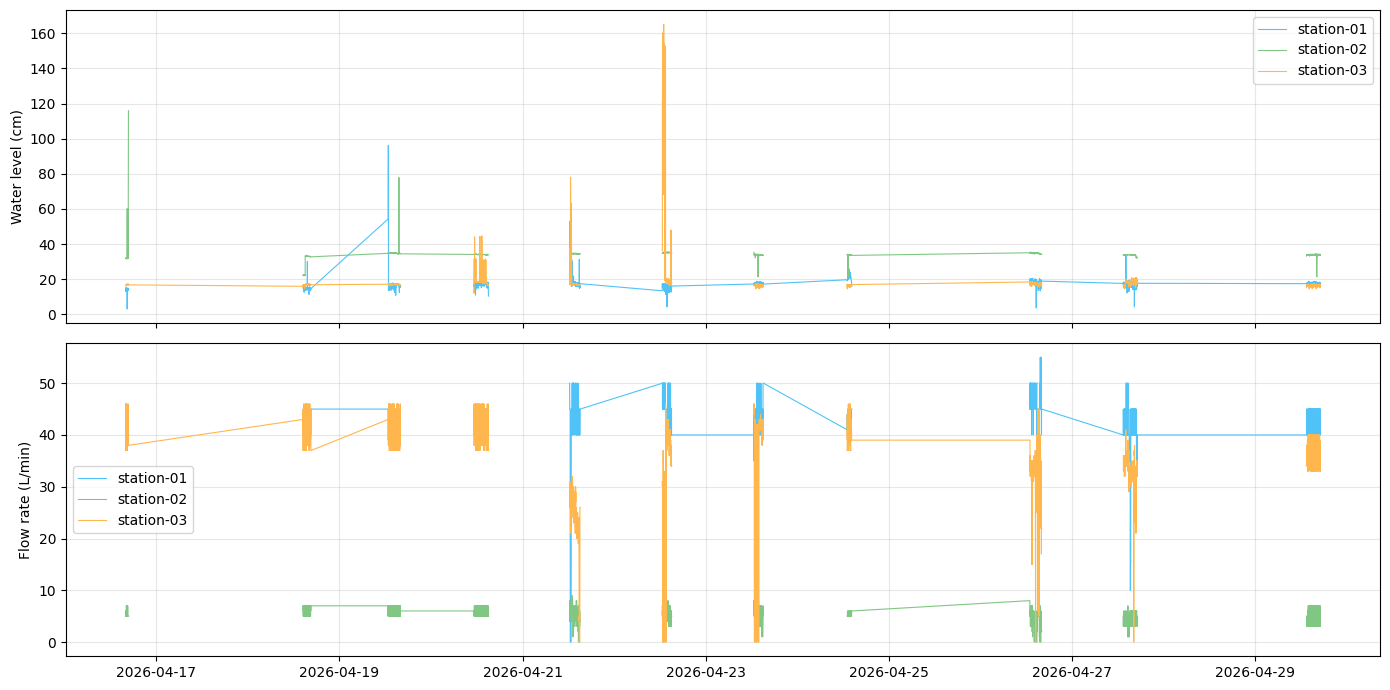

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
for sid, color in [('station-01', '#4fc3f7'), ('station-02', '#81c784'), ('station-03', '#ffb74d')]:
    axes[0].plot(wide.index, wide[f'{sid}_water_level'], label=sid, color=color, lw=0.8)
    axes[1].plot(wide.index, wide[f'{sid}_flow_rate'], label=sid, color=color, lw=0.8)
axes[0].set_ylabel('Water level (cm)'); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].set_ylabel('Flow rate (L/min)'); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout()

## Cross-correlation: upstream stations vs Centro

Positive lag = upstream series leads Centro (the expected direction).

{'station-02_water_level': (-52, 0.08769144835547632),
 'station-02_flow_rate': (-21, 0.053638399744992765),
 'station-03_water_level': (24, 0.07954635653239618),
 'station-03_flow_rate': (60, 0.06815755786809137)}

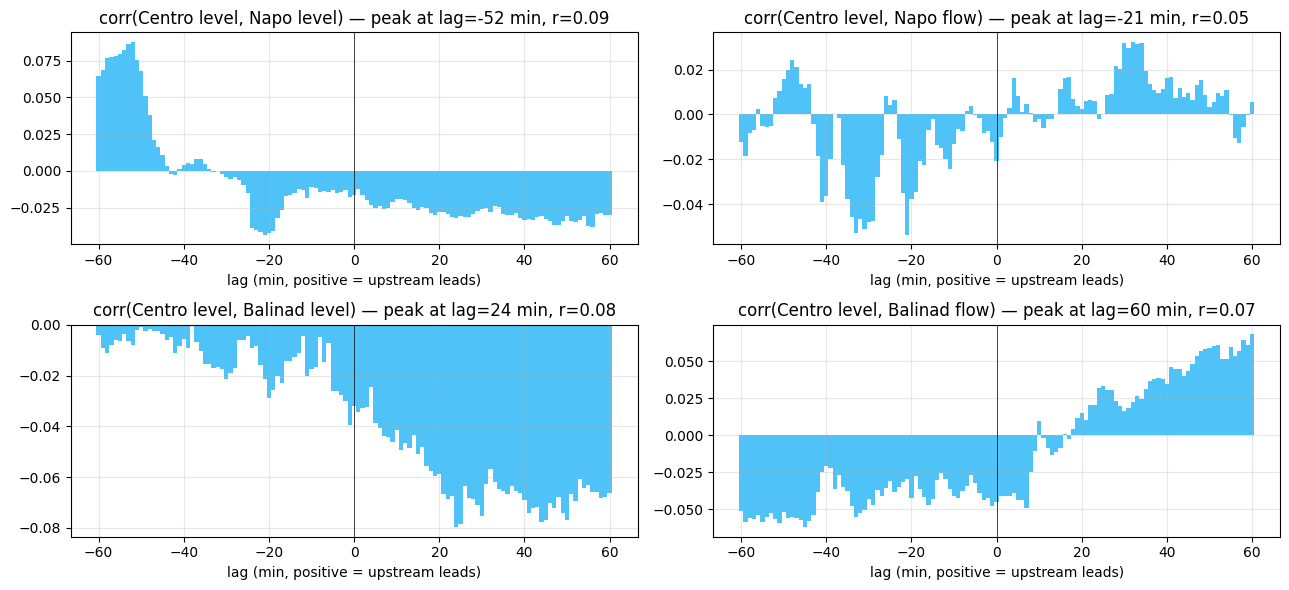

In [5]:
centro = wide['station-01_water_level']
results = {}
fig, axes = plt.subplots(2, 2, figsize=(13, 6))
pairs = [
    ('station-02_water_level', 'Napo level'),
    ('station-02_flow_rate', 'Napo flow'),
    ('station-03_water_level', 'Balinad level'),
    ('station-03_flow_rate', 'Balinad flow'),
]
for ax, (col, label) in zip(axes.flat, pairs):
    lags, corr = cross_correlation(centro, wide[col], max_lag_min=60)
    ax.bar(lags, corr, width=1, color='#4fc3f7')
    ax.axvline(0, color='k', lw=0.5)
    ax.set_title(f'corr(Centro level, {label}) — peak at lag={lags[np.nanargmax(np.abs(corr))]} min, r={np.nanmax(np.abs(corr)):.2f}')
    ax.set_xlabel('lag (min, positive = upstream leads)')
    ax.grid(alpha=0.3)
    results[col] = (int(lags[np.nanargmax(np.abs(corr))]), float(np.nanmax(np.abs(corr))))
plt.tight_layout()
results

**Interpretation:** if peak \|r\| < 0.3 on this calm dataset, the upstream signal is not yet visible — expected, since we haven't captured a rain event. The lag values still serve as priors for Phase 2 SARIMAX. Re-run after the first storm to validate.

## Stationarity + ACF/PACF for Centro level (informs SARIMAX order)

ADF stat=-7.922, p-value=0.0000  ->  stationary


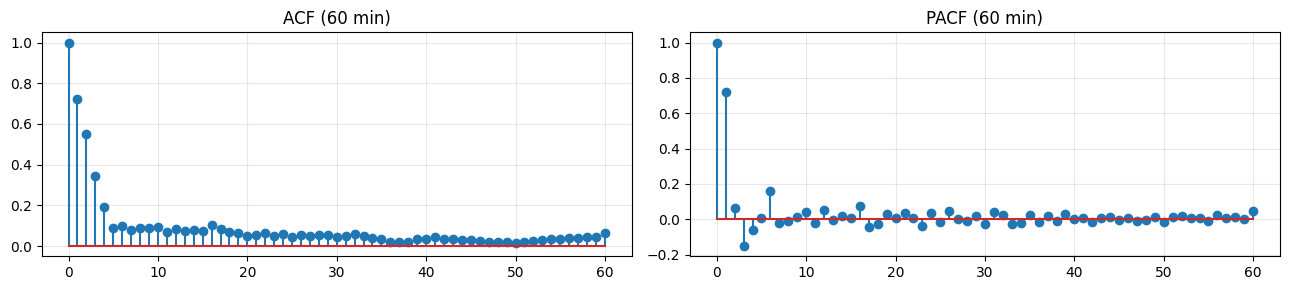

In [6]:
centro_clean = centro.dropna()
adf = adfuller(centro_clean)
print(f'ADF stat={adf[0]:.3f}, p-value={adf[1]:.4f}  ->  {"stationary" if adf[1] < 0.05 else "NON-stationary, will need d=1"}')

fig, axes = plt.subplots(1, 2, figsize=(13, 3))
axes[0].stem(acf(centro_clean, nlags=60))
axes[0].set_title('ACF (60 min)'); axes[0].grid(alpha=0.3)
axes[1].stem(pacf(centro_clean, nlags=60))
axes[1].set_title('PACF (60 min)'); axes[1].grid(alpha=0.3)
plt.tight_layout()

**Save lag results for Phase 2:**

In [7]:
import json
out_path = Path.cwd().parent / 'lags.json'
json.dump({k: {'lag_min': v[0], 'abs_corr': v[1]} for k, v in results.items()}, out_path.open('w'), indent=2)
print(f'Wrote {out_path}')

Wrote c:\Users\satui\OneDrive\Desktop\04 COMISSION_PROJECTS\bup-cpe-river\ml\lags.json
